<a href="https://colab.research.google.com/github/suranjit04/Python-Project-/blob/main/Phishing_Website_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phishing Website Detection by Machine Learning Techniques**

*Final project of AI & Cybersecurity Course*

## **1. Objective:**
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to train machine learning models and deep neural nets on the dataset created to predict phishing websites. Both phishing and benign URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measures and compared.

*This project is worked on Google Collaboratory.*<br>
*The required packages for this notebook are imported when needed.*

## **2. Loading Data:**

The features are extracted and store in the csv file. The working of this can be seen in the 'Phishing Website Detection_Feature Extraction.ipynb' file.

The reulted csv file is uploaded to this notebook and stored in the dataframe.

In [1]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading the data
data0 = pd.read_csv('/content/All.csv')
data0.head()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,4,5,5.5,14,4.400000,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.0,Defacement
1,0,4,5,5.5,14,6.000000,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.800000,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement
3,0,4,12,5.5,14,5.500000,4,32,16,0,...,0,0,-1,0.640130,0.784493,0.814725,0.663210,0.0,-1.0,Defacement
4,0,4,6,5.5,14,7.333334,4,18,11,0,...,0,0,-1,0.681307,0.784493,0.814725,0.804526,0.0,-1.0,Defacement


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **3. Familiarizing with Data**
In this step, few dataframe methods are used to look into the data and its features.

In [4]:
#Checking the shape of the dataset
data0.shape

(36707, 80)

In [5]:
#Listing the features of the dataset
data0.columns

Index(['Querylength', 'domain_token_count', 'path_token_count',
       'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld',
       'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path',
       'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path',
       'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength',
       'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio',
       'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio',
       'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL',
       'ISIpAddressInDomainName', 'CharacterContinuityRate',
       'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount',
       'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount',
       'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count',
       'Directory_LetterCount', 'Filename_LetterCount',
       'Extension_LetterCount', 'Query_LetterCount', 'LongestPathToken

In [6]:
#Information about the dataset
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36707 entries, 0 to 36706
Data columns (total 80 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Querylength                      36707 non-null  int64  
 1   domain_token_count               36707 non-null  int64  
 2   path_token_count                 36707 non-null  int64  
 3   avgdomaintokenlen                36707 non-null  float64
 4   longdomaintokenlen               36707 non-null  int64  
 5   avgpathtokenlen                  36427 non-null  float64
 6   tld                              36707 non-null  int64  
 7   charcompvowels                   36707 non-null  int64  
 8   charcompace                      36707 non-null  int64  
 9   ldl_url                          36707 non-null  int64  
 10  ldl_domain                       36707 non-null  int64  
 11  ldl_path                         36707 non-null  int64  
 12  ldl_filename      

## **4. Visualizing the data**
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

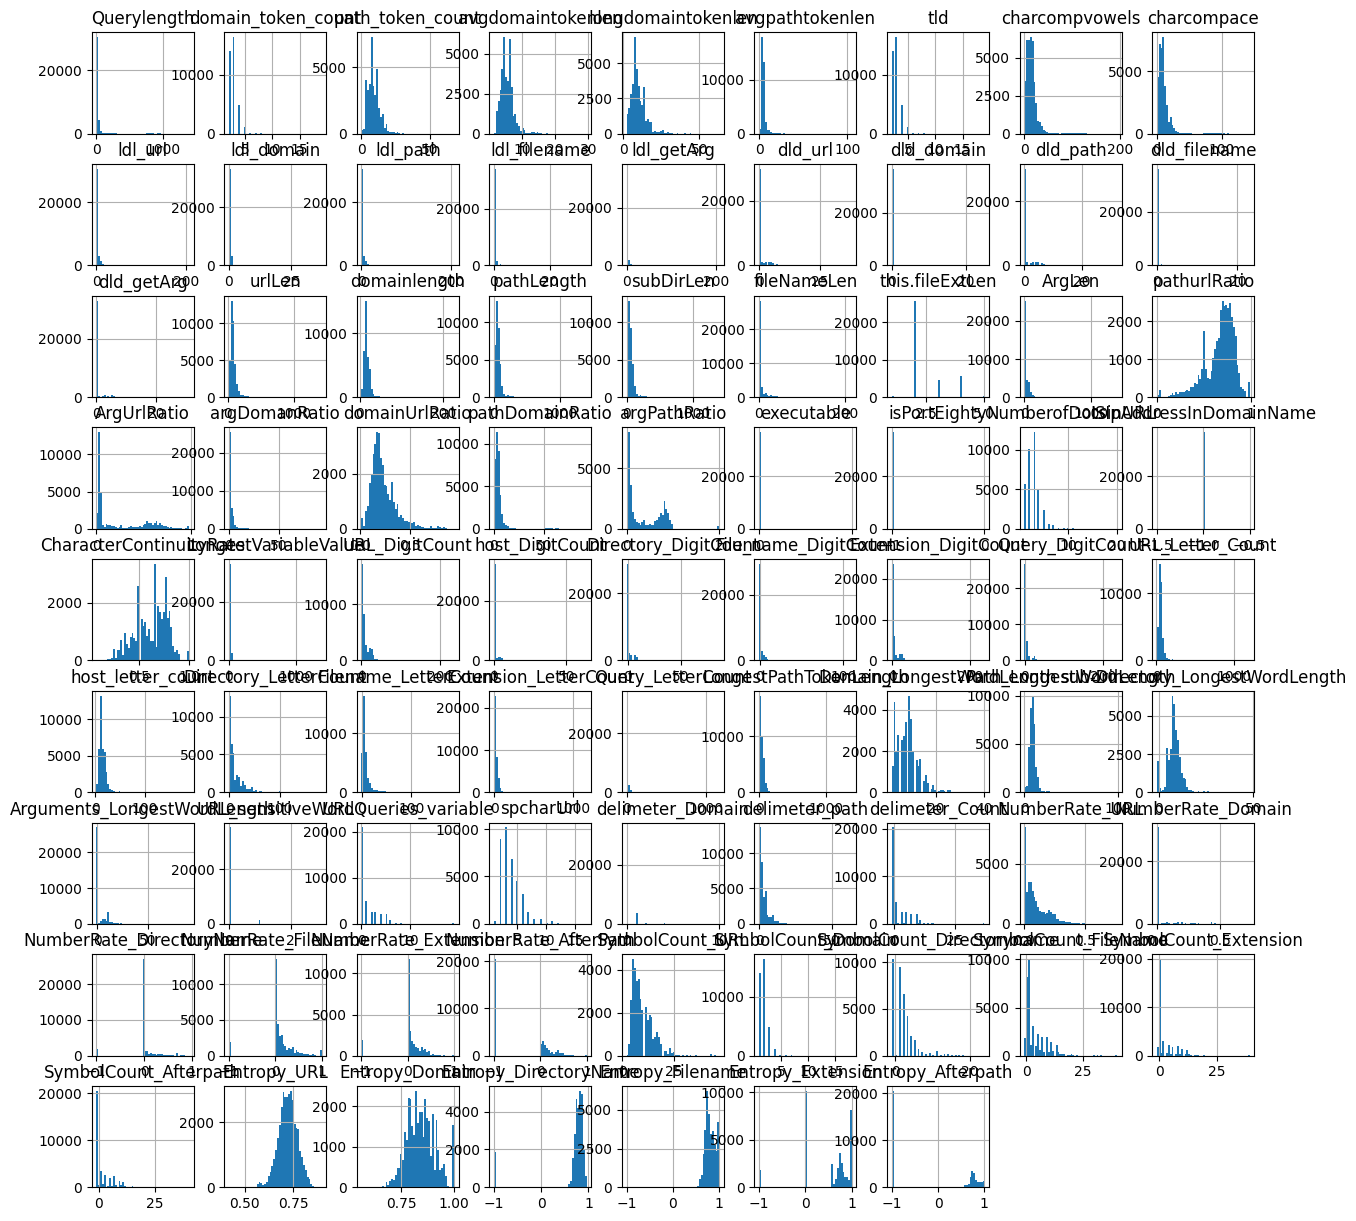

In [7]:
data0_cleaned = data0.replace([np.inf, -np.inf], np.nan)
data0_cleaned.hist(bins = 50,figsize = (15,15))
plt.show()

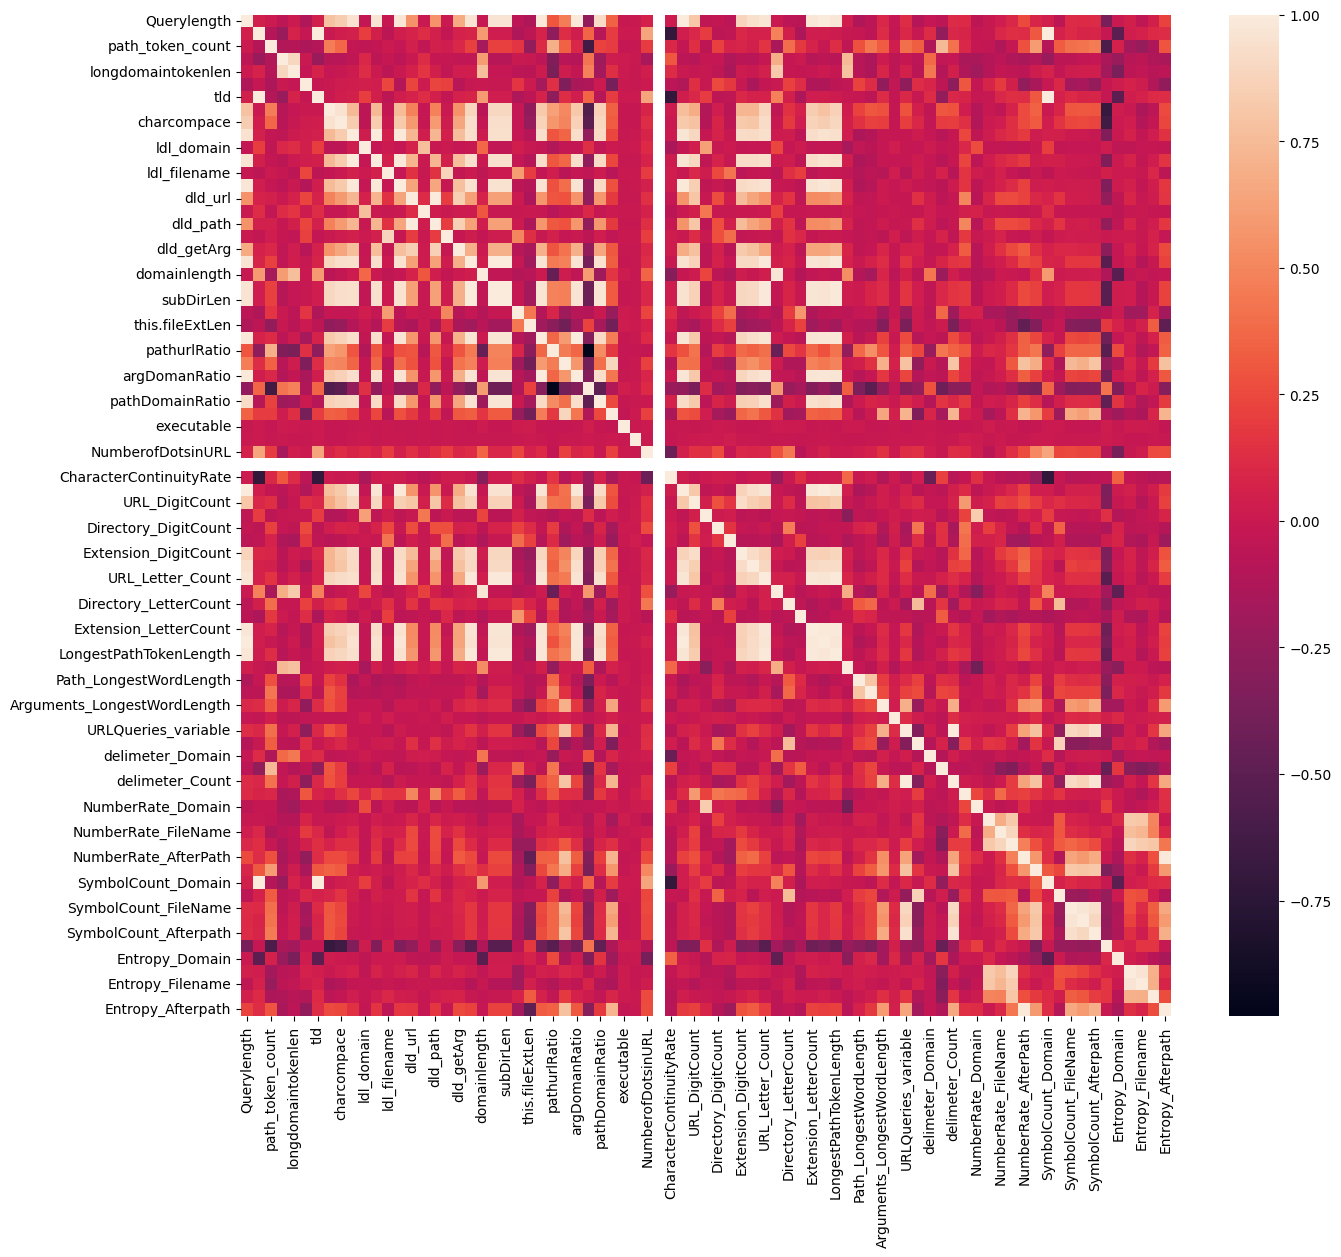

In [8]:
#Correlation heatmap

plt.figure(figsize=(15,13))
sns.heatmap(data0.drop('URL_Type_obf_Type', axis=1).corr())
plt.show()

## **5. Data Preprocessing & EDA**
Here, we clean the data by applying data preprocesssing techniques and transform the data to use it in the models.

In [9]:
data0.describe()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_Directoryname,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath
count,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36427.000000,36707.000000,36707.000000,36707.000000,36707.000000,...,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,36707.000000,28239.000000,36471.000000,36667.000000,36701.000000
mean,21.908110,2.857439,8.954668,5.401719,9.746016,4.556261,2.857439,14.976517,10.216117,3.363909,...,1.727545,3.600049,2.685237,1.903261,0.722350,0.842443,0.677459,0.715834,0.508212,-0.208900
std,94.280669,0.906562,4.278406,1.986858,4.856580,2.839388,0.906562,13.351315,10.845807,13.447289,...,2.719231,4.783213,4.557171,4.512421,0.048820,0.066251,0.450683,0.411712,0.519695,0.891581
min,0.000000,2.000000,0.000000,1.500000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,0.419560,0.561913,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,2.000000,6.000000,4.000000,6.000000,3.000000,2.000000,7.000000,5.000000,0.000000,...,-1.000000,0.000000,0.000000,-1.000000,0.691929,0.795234,0.731621,0.719904,0.000000,-1.000000
50%,0.000000,3.000000,8.000000,5.000000,9.000000,4.100000,3.000000,13.000000,8.000000,0.000000,...,1.000000,1.000000,0.000000,-1.000000,0.723003,0.835752,0.790535,0.785150,0.729292,-1.000000
75%,19.000000,3.000000,11.000000,6.500000,12.000000,5.000000,3.000000,19.000000,12.000000,1.000000,...,3.000000,6.000000,4.000000,3.000000,0.754305,0.884735,0.851410,0.884662,0.910005,0.758695
max,1385.000000,19.000000,68.000000,29.500000,63.000000,105.000000,19.000000,193.000000,142.000000,207.000000,...,24.000000,40.000000,39.000000,40.000000,0.895403,1.000000,0.962479,1.000000,1.000000,1.000000


The above obtained result shows that the most of the data is made of 0's & 1's except 'Domain' & 'URL_Depth' columns. The Domain column doesnt have any significance to the machine learning model training. So dropping the *'Domain'* column from the dataset.

In [10]:
# Create a copy of the data
data = data0.copy()

# Replace infinite values with NaN
data = data.replace([np.inf, -np.inf], np.nan)

# Fill remaining NaN values with 0
data = data.fillna(0)


This leaves us with 16 features & a target column. The *'URL_Depth'* maximum value is 20. According to my understanding, there is no necessity to change this column.

In [11]:
#checking the data for null or missing values
data.isnull().sum()

,0
Querylength,0
domain_token_count,0
path_token_count,0
avgdomaintokenlen,0
longdomaintokenlen,0
...,...
Entropy_DirectoryName,0
Entropy_Filename,0
Entropy_Extension,0
Entropy_Afterpath,0


In the feature extraction file, the extracted features of legitmate & phishing url datasets are just concatenated without any shuffling. This resulted in top 5000 rows of legitimate url data & bottom 5000 of phishing url data.

To even out the distribution while splitting the data into training & testing sets, we need to shuffle it. This even evades the case of overfitting while model training.

In [12]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,3,8,3.0,5,5.000000,3,13,10,1,...,1,0,-1,0.794702,0.894886,0.796658,0.823606,1.000000,-1.000000,spam
1,62,5,30,2.4,3,4.666666,5,62,41,28,...,11,10,10,0.642654,0.769455,0.653239,0.701508,0.700269,0.691472,spam
2,13,2,13,4.5,6,3.000000,2,23,17,0,...,14,13,12,0.676591,0.796658,0.871049,0.692652,0.699647,0.695870,benign
3,0,2,11,2.5,3,5.636363,2,22,9,0,...,0,0,-1,0.695840,1.000000,0.674567,0.647486,0.000000,-1.000000,malware
4,40,2,9,10.5,18,2.666667,2,24,16,0,...,11,10,9,0.688213,0.829219,0.000000,0.717181,0.720581,0.711172,Defacement


From the above execution, it is clear that the data doesnot have any missing values.

By this, the data is throughly preprocessed & is ready for training.

## **6. Splitting the Data**

In [13]:
# Sepratating & assigning features and target columns to X & y
y = data['URL_Type_obf_Type']
X = data.drop('URL_Type_obf_Type',axis=1)
X.shape, y.shape

((36707, 79), (36707,))

In [14]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, random_state = 12)
X_train.shape, X_test.shape

((29365, 79), (7342, 79))

## **7. Machine Learning Models & Training**

From the dataset above, it is clear that this is a supervised machine learning task. There are two major types of supervised machine learning problems, called classification and regression.

This data set comes under classification problem, as the input URL is classified as phishing (1) or legitimate (0). The supervised machine learning models (classification) considered to train the dataset in this notebook are:
* Decision Tree
* Random Forest
* Multilayer Perceptrons
* XGBoost
* Autoencoder Neural Network
* Support Vector Machines

In [15]:
#importing packages
from sklearn.metrics import accuracy_score

### **7.4. XGBoost Classifier**
XGBoost is one of the most popular machine learning algorithms these days. XGBoost stands for eXtreme Gradient Boosting. Regardless of the type of prediction task at hand; regression or classification. XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.

In [16]:
from sklearn.preprocessing import LabelEncoder
#XGBoost Classification model
from xgboost import XGBClassifier

# Instantiate LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and transform y_test
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Ensure X_train and X_test are clean from infinite values and NaNs
X_train_cleaned = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_cleaned = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)
#fit the model
xgb.fit(X_train_cleaned, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test_cleaned)
y_train_xgb = xgb.predict(X_train_cleaned)

**Performance Evaluation:**

In [18]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train_encoded,y_train_xgb)
acc_test_xgb = accuracy_score(y_test_encoded,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 1.000
XGBoost : Accuracy on test Data: 0.985


**Storing the results:**

In [19]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

In [20]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,XGBoost,1.0,0.985


In [21]:
# save XGBoost model to file
import pickle
pickle.dump(xgb, open("XGBoostClassifier.pickle.dat", "wb"))

**Testing the saved model:**

In [22]:
# load model from file
loaded_model = pickle.load(open("XGBoostClassifier.pickle.dat", "rb"))
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:
pickle.dump(le, open("label_encoder.pkl", "wb"))

In [24]:
pickle.dump(X_train_cleaned.columns.tolist(),
            open("training_columns.pkl", "wb"))

In [25]:
import pickle

# Load model
loaded_model = pickle.load(
    open("XGBoostClassifier.pickle.dat", "rb")
)

# Load label encoder
le = pickle.load(open("label_encoder.pkl", "rb"))

# Load training columns
training_columns = pickle.load(
    open("training_columns.pkl", "rb")
)

In [26]:
test_url = "https://www.google.com"

In [27]:
import re
import socket
import requests
import urllib.parse
from urllib.parse import urlparse
import pandas as pd
import numpy as np
from collections import Counter

def extract_features(url):
    features = {}
    parsed = urlparse(url)

    # Handle cases where scheme is missing (e.g., "www.example.com")
    if not parsed.scheme:
        url_with_scheme = "http://" + url  # Default to http
        parsed = urlparse(url_with_scheme)
    else:
        url_with_scheme = url

    hostname = parsed.netloc
    path = parsed.path
    query = parsed.query
    fragment = parsed.fragment

    # Helper functions for new feature calculations
    def count_digits_in_string(s):
        return sum(c.isdigit() for c in s)

    def count_letters_in_string(s):
        return sum(c.isalpha() for c in s)

    def count_vowels(s):
        return sum(1 for char in s.lower() if char in 'aeiou')

    def count_ace_chars(s): # Assuming 'ace' refers to 'a', 'c', 'e' characters
        return sum(1 for char in s.lower() if char in 'ace')

    def calculate_entropy(s):
        if not s: return 0 # Changed from 0 to -1 to match dataset behavior for empty components
        p, lns = Counter(s), float(len(s))
        if lns == 0: return 0 # Should be caught by 'if not s', but for robustness
        return -sum(count/lns * np.log2(count/lns) for count in p.values())

    def longest_word_length(s): # Simple approximation for longest word
        words = re.findall(r'\b\w+\b', s) # Finds alphanumeric words
        return max(len(word) for word in words) if words else 0

    # Basic URL structure features
    features['urlLen'] = len(url)
    features['domainlength'] = len(hostname)
    features['pathLength'] = len(path)
    features['Querylength'] = len(query)
    features['ArgLen'] = len(query)  # Assuming ArgLen is Querylength

    # Token counts
    features['domain_token_count'] = len(hostname.split('.')) if hostname else 0
    features['path_token_count'] = len(path.split('/')) - 1 if path and path != '/' else 0
    features['NumberofDotsinURL'] = url.count('.')

    # Average token lengths (approximations)
    features['avgdomaintokenlen'] = np.mean([len(t) for t in hostname.split('.') if t]) if hostname else 0
    features['longdomaintokenlen'] = max([len(t) for t in hostname.split('.') if t]) if hostname else 0
    features['avgpathtokenlen'] = np.mean([len(t) for t in path.split('/') if t]) if path else 0 # data0.describe() min is 0
    features['LongestPathTokenLength'] = max([len(t) for t in path.split('/') if t]) if path else 0

    # Character counts (some might be redundant with newer features but kept for completeness)
    features['count_dots'] = url.count('.')
    features['count_hyphen'] = url.count('-')
    features['count_at'] = url.count('@')
    features['count_question'] = url.count('?')
    features['count_percent'] = url.count('%')
    features['count_equal'] = url.count('=')
    features['count_http'] = url.count('http')
    features['count_https'] = url.count('https')
    features['count_www'] = url.count('www')
    features['count_digits'] = sum(c.isdigit() for c in url)

    # Ratio features
    features['digit_ratio'] = features['count_digits'] / len(url) if len(url) > 0 else 0
    features['letter_ratio'] = sum(c.isalpha() for c in url) / len(url) if len(url) > 0 else 0
    features['pathurlRatio'] = features['pathLength'] / len(url) if len(url) > 0 else 0
    features['ArgUrlRatio'] = features['ArgLen'] / len(url) if len(url) > 0 else 0
    features['argDomanRatio'] = features['ArgLen'] / len(hostname) if len(hostname) > 0 else 0
    features['domainUrlRatio'] = len(hostname) / len(url) if len(url) > 0 else 0
    features['pathDomainRatio'] = features['pathLength'] / len(hostname) if len(hostname) > 0 else 0
    features['argPathRatio'] = features['ArgLen'] / features['pathLength'] if features['pathLength'] > 0 else 0

    # Boolean features
    features['has_ip'] = 1 if re.match(r'^\b((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}(25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\b$', hostname) else 0
    features['has_https_token'] = 1 if 'https' in hostname else 0
    features['is_https'] = 1 if parsed.scheme == 'https' else 0
    features['uses_shortener'] = 1 if any(short in hostname for short in ['bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly', 'is.gd', 'buff.ly']) else 0
    features['has_suspicious_words'] = 1 if any(word in url.lower() for word in ['login', 'verify', 'secure', 'account', 'update', 'banking', 'confirm', 'signin']) else 0
    features['executable'] = 1 if re.search(r'\.(exe|zip|rar|dll)$', path, re.IGNORECASE) else 0 # Approximation
    features['isPortEighty'] = 1 if parsed.port == 80 else 0 # Default port is often implied if not present
    features['ISIpAddressInDomainName'] = features['has_ip'] # Alias for consistency

    # Directory and file related features (approximations)
    path_tokens = [t for t in path.split('/') if t]
    last_path_token = ''
    if path_tokens:
        last_path_token = path_tokens[-1]

    file_extension_token = ''
    if last_path_token and '.' in last_path_token:
        parts = last_path_token.rsplit('.', 1)
        if len(parts) > 1:
            file_extension_token = parts[1]

    features['subDirLen'] = len(last_path_token) # Length of last directory/file token. data0.describe() min is 0.
    features['fileNameLen'] = 0 # Default if no clear filename. data0.describe() min is 0.
    features['this.fileExtLen'] = 0 # Default if no clear file extension. data0.describe() min is 0.

    if last_path_token and '.' in last_path_token:
        parts = last_path_token.rsplit('.', 1)
        features['fileNameLen'] = len(parts[0]) # Part before last dot
        if len(parts) > 1:
            features['this.fileExtLen'] = len(parts[1]) # Part after last dot
        else:
            features['fileNameLen'] = len(last_path_token) # If no extension, whole thing is filename

    # *** NEW FEATURES ADDED ***
    features['tld'] = len(hostname.split('.')[-1]) if hostname and '.' in hostname else 0
    features['charcompvowels'] = count_vowels(url)
    features['charcompace'] = count_ace_chars(url)

    # Digit Counts
    features['URL_DigitCount'] = count_digits_in_string(url)
    features['host_DigitCount'] = count_digits_in_string(hostname)
    features['Directory_DigitCount'] = count_digits_in_string(path)
    features['File_name_DigitCount'] = count_digits_in_string(last_path_token) # Using last_path_token as approximation for filename
    features['Extension_DigitCount'] = count_digits_in_string(file_extension_token)
    features['Query_DigitCount'] = count_digits_in_string(query)

    # Letter Counts
    features['URL_Letter_Count'] = count_letters_in_string(url)
    features['host_letter_count'] = count_letters_in_string(hostname)
    features['Directory_LetterCount'] = count_letters_in_string(path)
    features['Filename_LetterCount'] = count_letters_in_string(last_path_token)
    features['Extension_LetterCount'] = count_letters_in_string(file_extension_token)
    features['Query_LetterCount'] = count_letters_in_string(query)

    # CharacterContinuityRate, LongestVariableValue (Approximated as 0 or simple calc for now)
    # CharacterContinuityRate is complex without original definition. Defaulting to 0.
    features['CharacterContinuityRate'] = 0
    features['LongestVariableValue'] = 0 # No clear way to extract 'variables' from query without specific structure knowledge

    # Longest Word Length features
    features['Domain_LongestWordLength'] = longest_word_length(hostname)
    features['Path_LongestWordLength'] = longest_word_length(path)
    features['sub-Directory_LongestWordLength'] = longest_word_length(last_path_token) # Using last_path_token as sub-directory/filename
    features['Arguments_LongestWordLength'] = longest_word_length(query)

    # Special character count in URL
    features['spcharUrl'] = sum(1 for char in url if not (char.isalnum() or char in ['.', '/', ':', '?', '=', '&'])) # Simple approximation of special characters

    # *** END NEW FEATURES ***

    # Number rate features (ratio of digits to total characters)
    # These are recalculated to use the more precise helper functions and -1 for empty components
    features['NumberRate_URL'] = features['URL_DigitCount'] / len(url) if len(url) > 0 else 0
    features['NumberRate_Domain'] = features['host_DigitCount'] / len(hostname) if len(hostname) > 0 else 0
    features['NumberRate_DirectoryName'] = features['Directory_DigitCount'] / len(path) if len(path) > 0 else 0 # Changed from 0 to -1
    features['NumberRate_FileName'] = features['File_name_DigitCount'] / len(last_path_token) if last_path_token else 0 # Changed from 0 to -1
    features['NumberRate_Extension'] = features['Extension_DigitCount'] / len(file_extension_token) if file_extension_token else 0 # Changed from 0 to -1
    features['NumberRate_AfterPath'] = count_digits_in_string(query + fragment) / len(query + fragment) if len(query + fragment) > 0 else 0 # Changed from 0 to -1

    # Symbol Count features (already present, ensured \ is properly escaped)
    all_symbols = ['/', '.', '-', '_', '?', '=', '&', '%', '@', '~', '!', '$', '^', '*', '(', ')', '+', '{', '}', '[', ']', '|', '\\', ':', ';', '<', '>', ',']
    for sym in all_symbols:
        features[f'count_{sym}'] = url.count(sym)

    features['SymbolCount_URL'] = sum(url.count(s) for s in all_symbols)
    features['SymbolCount_Domain'] = sum(hostname.count(s) for s in all_symbols)
    features['SymbolCount_Directoryname'] = sum(path.count(s) for s in all_symbols) if path else 0 # Changed from 0 to -1
    features['SymbolCount_FileName'] = sum(last_path_token.count(s) for s in all_symbols) if last_path_token else 0 # Changed from 0 to -1
    features['SymbolCount_Extension'] = sum(file_extension_token.count(s) for s in all_symbols) if file_extension_token else 0 # Changed from 0 to -1
    features['SymbolCount_Afterpath'] = sum((query + fragment).count(s) for s in all_symbols) if (query + fragment) else 0 # Changed from 0 to -1

    # Entropy features (re-using helper function; calculate_entropy now returns -1 for empty strings)
    features['Entropy_URL'] = calculate_entropy(url)
    features['Entropy_Domain'] = calculate_entropy(hostname)
    features['Entropy_DirectoryName'] = calculate_entropy(path)
    features['Entropy_Filename'] = calculate_entropy(last_path_token)
    features['Entropy_Extension'] = calculate_entropy(file_extension_token)
    features['Entropy_Afterpath'] = calculate_entropy(query + fragment)

    # URL_sensitiveWord, URLQueries_variable (already present)
    features['URL_sensitiveWord'] = 1 if 'admin' in url.lower() or 'password' in url.lower() else 0
    features['URLQueries_variable'] = len(query.split('&')) if query else 0

    # ldl (Letter Digit Letter) and dld (Digit Letter Digit) counts - Simplified (already present)
    def count_ldl_pattern(s): return len(re.findall(r'[a-zA-Z][0-9][a-zA-Z]', s))
    def count_dld_pattern(s): return len(re.findall(r'[0-9][a-zA-Z][0-9]', s))

    features['ldl_url'] = count_ldl_pattern(url)
    features['ldl_domain'] = count_ldl_pattern(hostname)
    features['ldl_path'] = count_ldl_pattern(path)
    features['ldl_filename'] = count_ldl_pattern(last_path_token)
    features['ldl_getArg'] = count_ldl_pattern(query)

    features['dld_url'] = count_dld_pattern(url)
    features['dld_domain'] = count_dld_pattern(hostname)
    features['dld_path'] = count_dld_pattern(path)
    features['dld_filename'] = count_dld_pattern(last_path_token)
    features['dld_getArg'] = count_dld_pattern(query)

    # Other delimeter counts (already present)
    features['delimeter_Domain'] = sum(hostname.count(s) for s in ['-', '.'])
    features['delimeter_path'] = sum(path.count(s) for s in ['/', '-', '.'])
    features['delimeter_Count'] = features['delimeter_Domain'] + features['delimeter_path'] + query.count('&')

    # Uppercase/lowercase counts (added for general feature set)
    features['uppercase_count'] = sum(1 for c in url if c.isupper())
    features['lowercase_count'] = sum(1 for c in url if c.islower())

    # Ensure all training columns are present, filling with 0 if not calculated
    for col in training_columns:
        if col not in features:
            features[col] = 0

    # Convert features to a DataFrame
    df = pd.DataFrame([features])  # Keep ONLY training columns
    df = df.reindex(columns=training_columns, fill_value=0)
    return df

In [28]:
def predict_url(url):

    features = extract_features(url)

    features.replace([np.inf, -np.inf], np.nan, inplace=True)
    features.fillna(0, inplace=True)

    pred = loaded_model.predict(features)

    result = le.inverse_transform(pred)

    return result[0]

In [31]:
test_urls = [
    "http://timepay.ai",
    "http://abc.org/news.html",
    "http://paypal-login-security-update.free-host.com",
    "http://appleid.apple.verify-user-access.com"
]

for url in test_urls:
    result = predict_url(url)
    print(f"{url} --> {result}")

http://timepay.ai --> phishing
http://abc.org/news.html --> Defacement
http://paypal-login-security-update.free-host.com --> phishing
http://appleid.apple.verify-user-access.com --> phishing


In [38]:
safe_urls = [
    "https://www.google.com",
    "https://github.com",
    "https://openai.com",
    "https://stackoverflow.com",
    "https://www.microsoft.com",
    "https://www.apple.com",
    "https://www.amazon.in",
    "https://kaggle.com",
    "https://colab.research.google.com",
    "https://www.wikipedia.org"
]

phishing_urls = [
    "http://paypal-login-security-update.free-host.com",
    "http://appleid.apple.verify-user-access.com",
    "http://verify-your-bank-account-login.xyz",
    "http://secure-update-paypal-account.cf/login",
    "http://microsoft-security-alert.tk/verify",
]

malware_urls = [
    "http://free-software-download-crack.ru/setup.exe",
    "http://malicious-site.com/trojan.zip",
]

spam_urls = [
    "http://win-free-iphone-now.click",
    "http://lottery-winner-claim-prize.xyz",
]

defacement_urls = [
    "http://example.com/index.php",
    "http://abc.org/news.html",
]

test_urls = (
    safe_urls +
    phishing_urls +
    malware_urls +
    spam_urls +
    defacement_urls
)

for url in test_urls:
    result = predict_url(url)
    print(f"{url} --> {result}")

https://www.google.com --> Defacement
https://github.com --> phishing
https://openai.com --> phishing
https://stackoverflow.com --> phishing
https://www.microsoft.com --> spam
https://www.apple.com --> Defacement
https://www.amazon.in --> Defacement
https://kaggle.com --> phishing
https://colab.research.google.com --> spam
https://www.wikipedia.org --> spam
http://paypal-login-security-update.free-host.com --> phishing
http://appleid.apple.verify-user-access.com --> phishing
http://verify-your-bank-account-login.xyz --> phishing
http://secure-update-paypal-account.cf/login --> phishing
http://microsoft-security-alert.tk/verify --> phishing
http://free-software-download-crack.ru/setup.exe --> phishing
http://malicious-site.com/trojan.zip --> malware
http://win-free-iphone-now.click --> phishing
http://lottery-winner-claim-prize.xyz --> phishing
http://example.com/index.php --> Defacement
http://abc.org/news.html --> Defacement
